In [4]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().clear_cache()
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner
from ipywidgets import *
import glob

In [13]:
h2o_xsec = OpacityCache()['H2O']
ch4_xsec = OpacityCache()['CH4']
co2_xsec = OpacityCache()['CO2']
co_xsec = OpacityCache()['CO']
nh3_xsec = OpacityCache()['NH3']
o2_xsec = OpacityCache()['O2']
so2_xsec = OpacityCache()['SO2']

''

In [16]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_transit = [n * 3600 for n in planet_transit] #hours to seconds
T_transit_hours = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data

star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

In [ ]:
%matplotlib widget

fig = figure(figsize=(8, 4), dpi=100)
frame = fig.add_subplot(1, 1, 1)

wavenumber = h2o_xsec.wavenumberGrid
frame.set_xlim(0.3, 8) #cover Ariel wavelength range
frame.set_xlabel("Wavelength (microns)")
frame.set_ylabel("Opacity (cm^2/molecule)")

xsec, = frame.plot(1e4/wavenumber, h2o_xsec.opacity(1500, 1.0*1e5)) #micron, cm^2/molecule | Kelvin, Pa

def update_cross(temperature=1500.0, pressure_bar=1.0):
    pressure_pa = pressure_bar * 1e5  # convert bar to Pa
    xsec.set_ydata(h2o_xsec.opacity(temperature, pressure_pa))
    frame.relim()
    frame.autoscale_view()
    fig.canvas.draw()

interact(update_cross, temperature=(300.0, 4000.0, 50), pressure_bar=(0.001, 3000.0, 1));

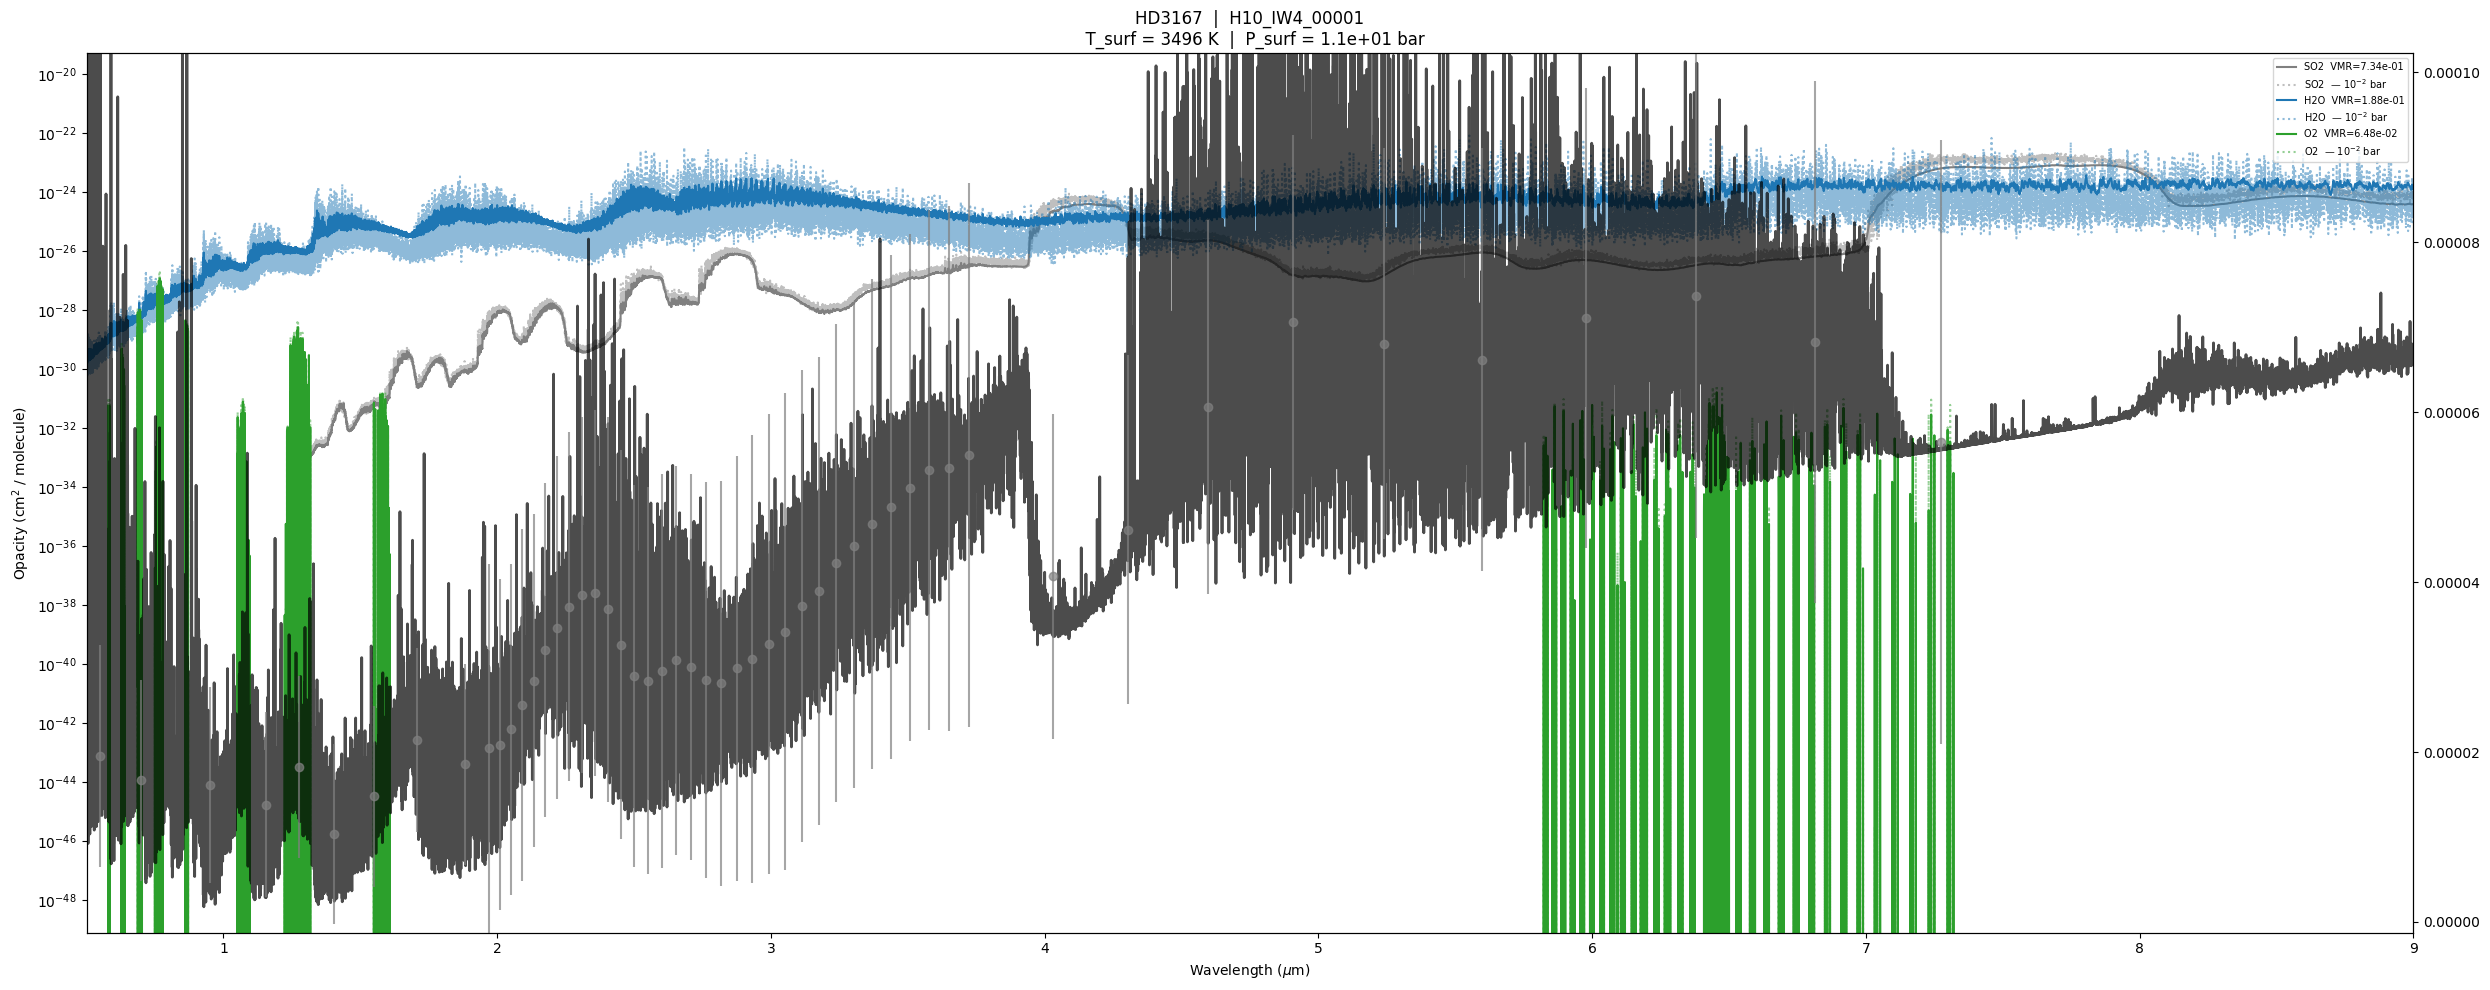

In [46]:
# Map molecule names to loaded xsec objects (only those with available cross-section data)
mol_to_xsec = {
    'H2O':  h2o_xsec,
    'CH4':  ch4_xsec,
    'CO2':  co2_xsec,
    'CO':   co_xsec,
    'NH3':  nh3_xsec,
    'O2':   o2_xsec,
    'SO2':  so2_xsec,
}

wavenumber_grid = h2o_xsec.wavenumberGrid
wavelength_um = 1e4 / wavenumber_grid  # microns

MOL_COLORS = {
    'H2O': 'tab:blue',
    'CO2': 'tab:orange',
    'O2':  'tab:green',
    'SO2': 'gray',
    'CO':  'tab:pink',
    'CH4': 'tab:red',
    'NH3': 'tab:purple',
}
tp_files = sorted(glob.glob('PLANETS/*/*_TP.csv'))

for tp_file in tp_files:
    parts = tp_file.replace('\\', '/').split('/')
    planet_name = parts[1]
    sim_name    = parts[2].replace('_TP.csv', '')

    name = planet_name
    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass_jup = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU

    radius = planet_radius[planet_names.index(name)] #planet radius in m

    #convert to Jupiter radii
    radius_jup = radius * (astropy.constants.R_earth.value / astropy.constants.R_jup.value)

    #set-up planet in Jupiter masses and radii
    pl = Planet(planet_mass=mass_jup, planet_radius= radius_jup, planet_sma=a, planet_distance=star_distance[planet_names.index(name)], 
                impact_param=planet_impact[planet_names.index(name)], orbital_period=planet_period[planet_names.index(name)], 
                transit_time=planet_transit[planet_names.index(name)])

    st = PhoenixStar(temperature=star_temperature[planet_names.index(name)], radius=star_radius[planet_names.index(name)], metallicity=star_metallicity[planet_names.index(name)],distance=star_distance[planet_names.index(name)], phoenix_path='Phoenix/')

    # --- Read TP profile ---
    tp_data         = pd.read_csv(tp_file)
    pressure_pa     = tp_data['Pressure (Pa)'].values          # Pa, descending (surface first)
    temp_substellar = tp_data['Substellar Temperature (K)'].values

    # Surface conditions (highest pressure = first row)
    surf_p_pa = pressure_pa[0]
    top_pa = pressure_pa[-1]
    surf_t    = temp_substellar[0]

    p1 = SimplePressureProfile(nlayers=100, atm_min_pressure=np.min(top_pa), atm_max_pressure=np.max(surf_p_pa))
    p1.compute_pressure_profile()

    # Conditions at 10^-2 bar (= 1000 Pa)
    target_p_pa = 1e-2 * 1e5
    idx_mid     = np.argmin(np.abs(pressure_pa - target_p_pa))
    mid_t       = temp_substellar[idx_mid]

    tp1 = TemperatureFile(f'PLANETS/{planet_name}/{sim_name}_TP.csv', skiprows=1,
                               temp_col=2, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    simulation_folder = os.path.join(f"PLANETS/{name}/{sim_name}")
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue
    for file in os.listdir(f"./{simulation_folder}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"./{simulation_folder}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    #build emission model at the dayside
    em_dayside = EmissionModel( 
    planet=pl,
    temperature_profile=tp1,
    chemistry=chemistry,
    pressure_profile=p1,
    star=st,
    )

    em_dayside.add_contribution(AbsorptionContribution())
    em_dayside.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_dayside.add_contribution(RayleighContribution())

    em_dayside.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid_t, fpfs_t, tau_t, _ = em_dayside.model()

    wlgrid_t = 10000/wngrid_t[::-1]
    fpfs_t = fpfs_t[::-1]

    ariel = pd.read_csv(f'ARIEL/arielrad_{name}/tier2.csv',skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    N=20
    yerr = noise/np.sqrt(N)

    fb = FluxBinner(wl, wb)
    output_t = fb.bindown(wlgrid_t, fpfs_t)
    wl, flux, err, *_ = output_t


    # ---- Read chemistry from runtime_helpfile ----
    helpfile_path = f'PLANETS/{planet_name}/{sim_name}/runtime_helpfile.csv'
    if not os.path.exists(helpfile_path):
        print(f'[skip] No runtime_helpfile found at {helpfile_path}')
        continue

    helpdata = pd.read_csv(helpfile_path, sep='\t')
    last_row = helpdata.iloc[-1]


    mol_vmrs = {}
    for mol in mol_to_xsec:
        col = f'{mol}_vmr'
        if col in helpdata.columns:
            val = float(last_row[col])
            if val > 0:
                mol_vmrs[mol] = val

    top3 = []
    cumulative_vmr = 0.0
    for mol, vmr in sorted(mol_vmrs.items(), key=lambda x: x[1], reverse=True):
        top3.append((mol, vmr))
        cumulative_vmr += vmr
        if len(top3) >= 3 or cumulative_vmr >= 0.999:
            break

    fig2, ax2 = plt.subplots(figsize=(25, 10))
    for mol, vmr in top3:
        color = MOL_COLORS[mol]
        xsec_obj = mol_to_xsec[mol]
        op_surf  = xsec_obj.opacity(float(surf_t), float(surf_p_pa))
        op_mid   = xsec_obj.opacity(float(mid_t),  float(target_p_pa))

        ax2.plot(wavelength_um, op_surf, color=color, ls='-',  lw=1.5,
                 label=f'{mol}  VMR={vmr:.2e}')
        ax2.plot(wavelength_um, op_mid,  color=color, ls=':', lw=1.5,
                 label=f'{mol}  — $10^{{-2}}$ bar',alpha=0.5)
        
    #create second y-axis for the planet spectrum on the same plot
    ax2b = ax2.twinx()
    ax2b.plot(wlgrid_t,fpfs_t, color='black', ls='-', lw=2, alpha=0.7)
    ax2b.errorbar(wl, flux, yerr=noise/np.sqrt(N), fmt='o', color='grey', alpha=0.7)

    y_all = np.concatenate([output_t[1] + yerr, output_t[1] - yerr])
    ymin, ymax = y_all.min(), y_all.max()
    pad = 0.0001 * (ymax - ymin)
    plt.ylim(ymin - pad, ymax + pad)

    ax2.set_yscale('log')
    ax2.set_xlim(0.5, 9)
    ax2.set_xlabel(r'Wavelength ($\mu$m)')
    ax2.set_ylabel(r'Opacity (cm$^2$ / molecule)')
    ax2.set_title(f'{planet_name}  |  {sim_name}\n  T_surf = {surf_t:.0f} K  |  P_surf = {surf_p_pa/1e5:.1e} bar')
    ax2.legend(fontsize=7, loc='upper right')
    ax2.set_yticks([1e-20,1e-22, 1e-24, 1e-26, 1e-28, 1e-30, 1e-32, 1e-34, 1e-36, 1e-38, 1e-40, 1e-42, 1e-44, 1e-46, 1e-48])

    plt.tight_layout()
    plt.show()
    break
